# 03_R_Analytics

# NorthStar Urban Mobility and Logistics
## R Analytics
### Module: Databases and Analytics — S2 2026

This notebook performs statistical analysis and visualisation on the NorthStar dataset.
It identifies patterns in delivery failures, driver performance, complaint trends,
and hub efficiency using correlation analysis, group comparisons, and data visualisation.

In [ ]:
cat("Files found:\n")
print(list.files())
cat("\nclean_data.zip size:", file.info('clean_data.zip')$size, "bytes\n")
cat("northstar_data.zip size:", file.info('northstar_data.zip')$size, "bytes\n")

Files found:
[1] "clean_data.zip"        "northstar"             "northstar_dataset.zip"
[4] "sample_data"          

clean_data.zip size: 378964 bytes
northstar_data.zip size: NA bytes


1. Extract and load data

In [ ]:
# Extract clean data
unzip('clean_data.zip', exdir = 'clean', overwrite = TRUE)

cat("Extracted files:\n")
print(list.files('clean'))

Extracted files:
 [1] "app_events.csv"              "chart1_delivery_by_zone.png"
 [3] "chart2_driver_analysis.png"  "chart3_complaints.png"      
 [5] "chart4_hub_vehicles.png"     "complaints.csv"             
 [7] "customers.csv"               "deliveries.csv"             
 [9] "drivers.csv"                 "hubs.csv"                   
[11] "incidents.csv"               "orders.csv"                 
[13] "vehicles.csv"               


2. Load all tables

In [ ]:
customers  <- read.csv('clean/customers.csv')
orders     <- read.csv('clean/orders.csv')
deliveries <- read.csv('clean/deliveries.csv')
drivers    <- read.csv('clean/drivers.csv')
vehicles   <- read.csv('clean/vehicles.csv')
hubs       <- read.csv('clean/hubs.csv')
incidents  <- read.csv('clean/incidents.csv')
complaints <- read.csv('clean/complaints.csv')
app_events <- read.csv('clean/app_events.csv')

cat("All tables loaded successfully\n")
cat("Orders:", nrow(orders), "rows\n")
cat("Deliveries:", nrow(deliveries), "rows\n")
cat("Customers:", nrow(customers), "rows\n")
cat("Drivers:", nrow(drivers), "rows\n")
cat("Complaints:", nrow(complaints), "rows\n")

All tables loaded successfully
Orders: 1250 rows
Deliveries: 950 rows
Customers: 650 rows
Drivers: 170 rows
Complaints: 320 rows


3. Install and load packages

In [ ]:
install.packages("ggplot2")
install.packages("dplyr")
install.packages("corrplot")
install.packages("scales")

library(ggplot2)
library(dplyr)
library(corrplot)
library(scales)

cat("All packages loaded\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



All packages loaded


4.Statistical summary of key variables

In [ ]:
# Merge deliveries with orders and drivers for full analysis
del_full <- deliveries %>%
  left_join(orders[, c('order_id','pickup_zone','service_type','order_value','promised_window_hours')],
            by='order_id') %>%
  left_join(drivers[, c('driver_id','years_experience','training_score','driver_rating')],
            by='driver_id') %>%
  left_join(hubs[, c('hub_id','hub_name','zone','capacity_score')],
            by='hub_id')

# Add failure flag
del_full$failed  <- as.integer(del_full$delivery_status == 'Failed')
del_full$delayed <- as.integer(del_full$delivery_status == 'Delayed')

cat("=== Key Statistical Summary ===\n")
cat("\nDelivery Status Distribution:\n")
print(table(del_full$delivery_status))

cat("\nAvg fuel cost by delivery status:\n")
print(tapply(del_full$fuel_or_charge_cost, del_full$delivery_status, mean))

cat("\nAvg overrides by delivery status:\n")
print(tapply(del_full$manual_route_override_count, del_full$delivery_status, mean))

cat("\nAvg customer rating by delivery status:\n")
print(tapply(del_full$customer_rating_post_delivery, del_full$delivery_status, mean))

=== Key Statistical Summary ===

Delivery Status Distribution:

Delayed  Failed  OnTime 
    202     132     616 

Avg fuel cost by delivery status:
 Delayed   Failed   OnTime 
13.13871 13.14795 12.67805 

Avg overrides by delivery status:
  Delayed    Failed    OnTime 
1.0742574 1.0378788 0.9204545 

Avg customer rating by delivery status:
 Delayed   Failed   OnTime 
3.137871 3.056818 4.280114 


5.Correlation analysis

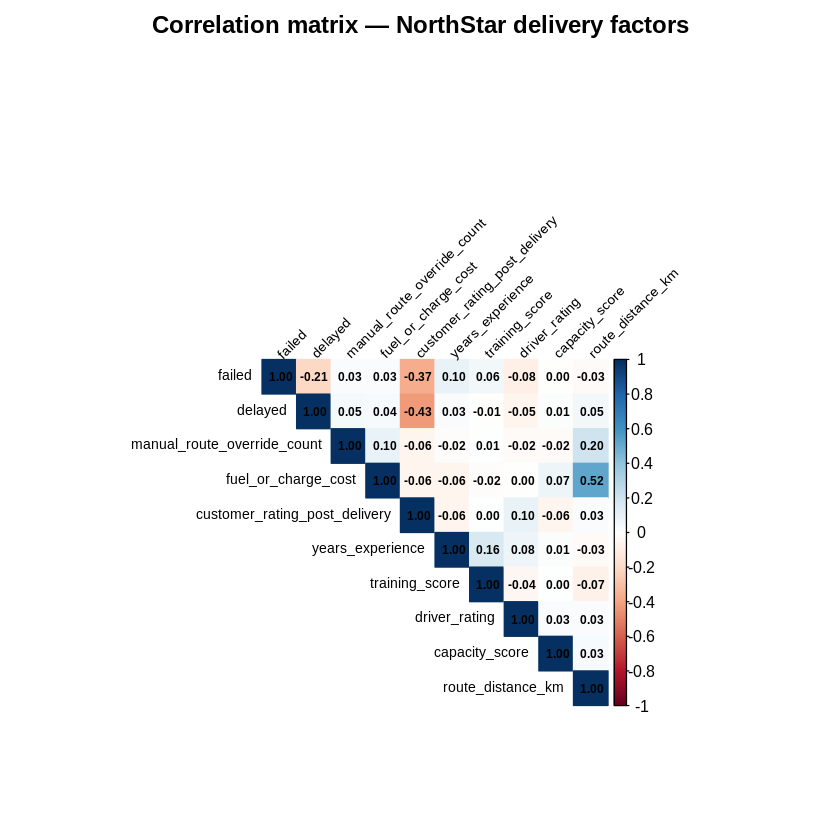

In [ ]:
# Select numeric variables for correlation
cor_data <- del_full %>%
  select(failed, delayed, manual_route_override_count,
         fuel_or_charge_cost, customer_rating_post_delivery,
         years_experience, training_score, driver_rating,
         capacity_score, route_distance_km) %>%
  na.omit()

corrplot(cor_matrix,
         method      = 'color',
         type        = 'upper',
         tl.cex      = 0.7,
         tl.col      = 'black',
         tl.srt      = 45,
         addCoef.col = 'black',
         number.cex  = 0.6,
         title       = 'Correlation matrix — NorthStar delivery factors',
         mar         = c(0,0,2,0))

6. Visualisation 1: Failure rate by zone

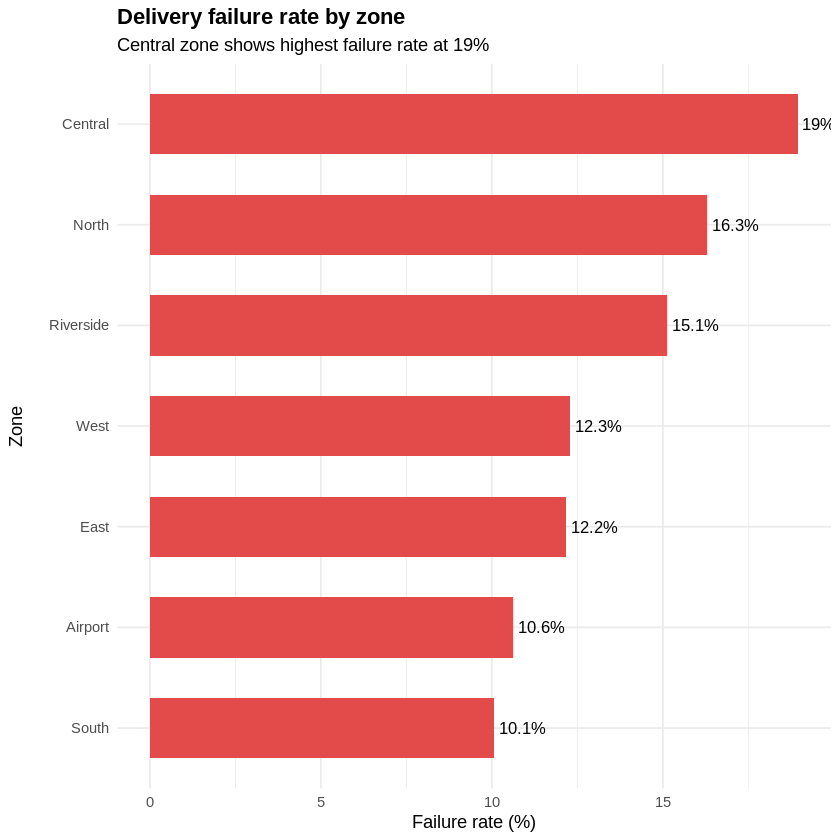

In [ ]:
zone_perf <- del_full %>%
  group_by(pickup_zone) %>%
  summarise(
    total         = n(),
    failure_rate  = mean(failed)  * 100,
    delay_rate    = mean(delayed) * 100,
    avg_cost      = mean(fuel_or_charge_cost)
  ) %>%
  arrange(desc(failure_rate))

ggplot(zone_perf, aes(x = reorder(pickup_zone, failure_rate), y = failure_rate)) +
  geom_bar(stat='identity', fill='#E24B4A', width=0.6) +
  geom_text(aes(label = paste0(round(failure_rate,1),'%')),
            hjust = -0.1, size = 3.5) +
  coord_flip() +
  labs(title    = 'Delivery failure rate by zone',
       subtitle = 'Central zone shows highest failure rate at 19%',
       x = 'Zone', y = 'Failure rate (%)') +
  theme_minimal() +
  theme(plot.title = element_text(face='bold'))

7. Visualisation 2: Driver experience vs failure rate

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


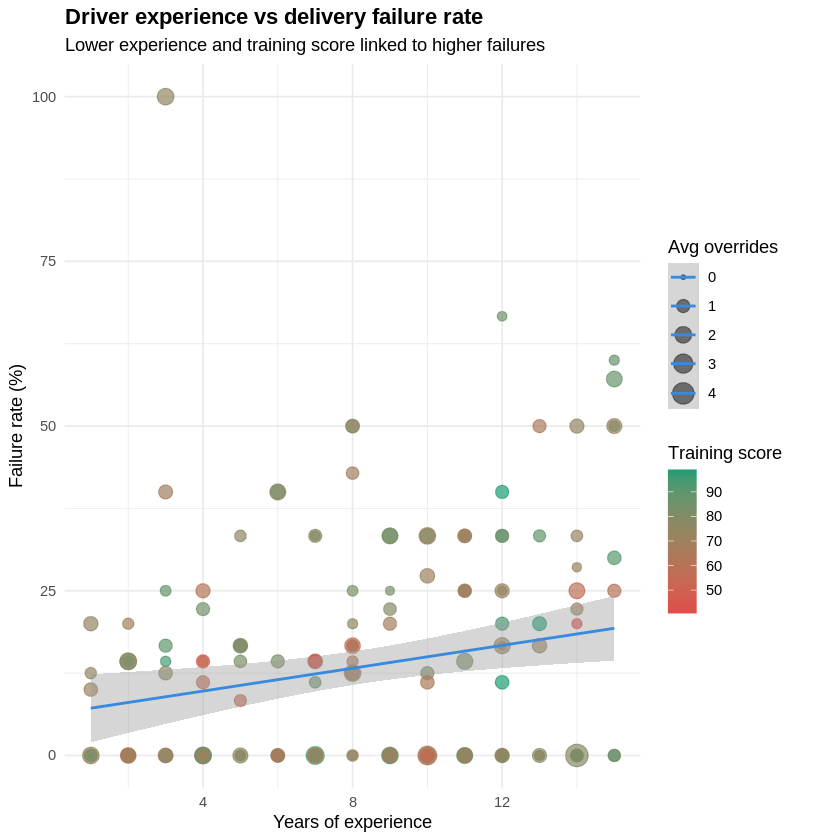

In [ ]:
driver_perf <- del_full %>%
  group_by(driver_id, years_experience, training_score, driver_rating) %>%
  summarise(
    total        = n(),
    failure_rate = mean(failed) * 100,
    avg_overrides = mean(manual_route_override_count),
    .groups = 'drop'
  )

ggplot(driver_perf, aes(x = years_experience, y = failure_rate,
                         colour = training_score, size = avg_overrides)) +
  geom_point(alpha = 0.7) +
  scale_colour_gradient(low='#E24B4A', high='#1D9E75', name='Training score') +
  scale_size_continuous(name='Avg overrides') +
  geom_smooth(method='lm', se=TRUE, colour='#378ADD', linewidth=0.8) +
  labs(title    = 'Driver experience vs delivery failure rate',
       subtitle = 'Lower experience and training score linked to higher failures',
       x = 'Years of experience', y = 'Failure rate (%)') +
  theme_minimal() +
  theme(plot.title = element_text(face='bold'))

8.Visualisation 3: Complaint trends over time

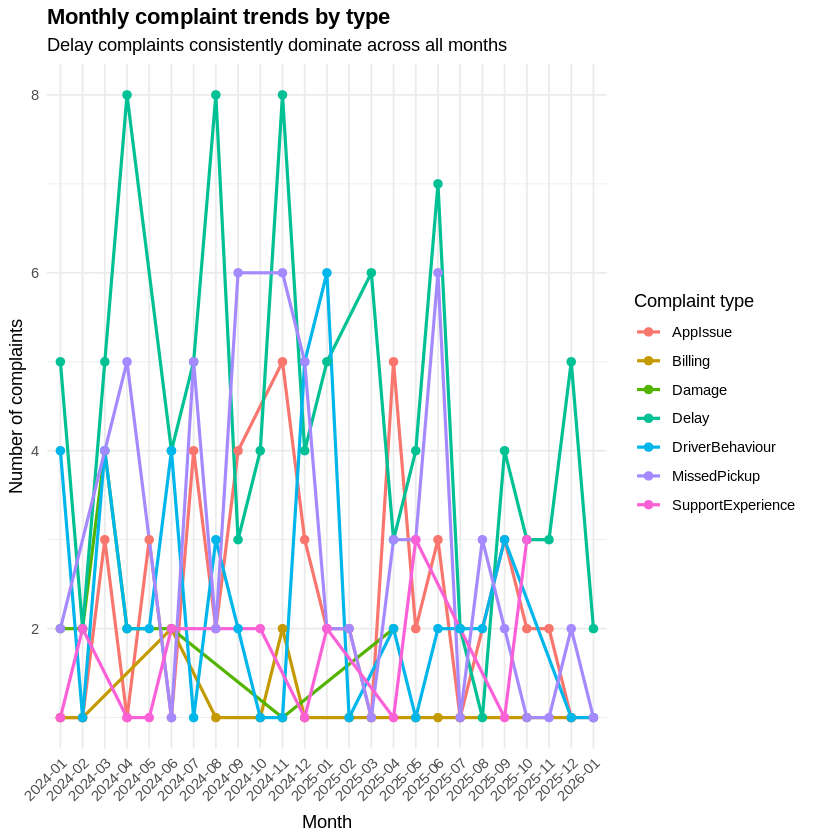

In [ ]:
complaints$created_at <- as.Date(complaints$created_at)
complaints$month      <- format(complaints$created_at, '%Y-%m')

monthly_complaints <- complaints %>%
  group_by(month, complaint_type) %>%
  summarise(count = n(), .groups='drop')

ggplot(monthly_complaints, aes(x = month, y = count,
                                group = complaint_type,
                                colour = complaint_type)) +
  geom_line(size = 0.9) +
  geom_point(size = 2) +
  labs(title    = 'Monthly complaint trends by type',
       subtitle = 'Delay complaints consistently dominate across all months',
       x = 'Month', y = 'Number of complaints',
       colour = 'Complaint type') +
  theme_minimal() +
  theme(plot.title    = element_text(face='bold'),
        axis.text.x   = element_text(angle=45, hjust=1))

9. Visualisation 4: Service type performance

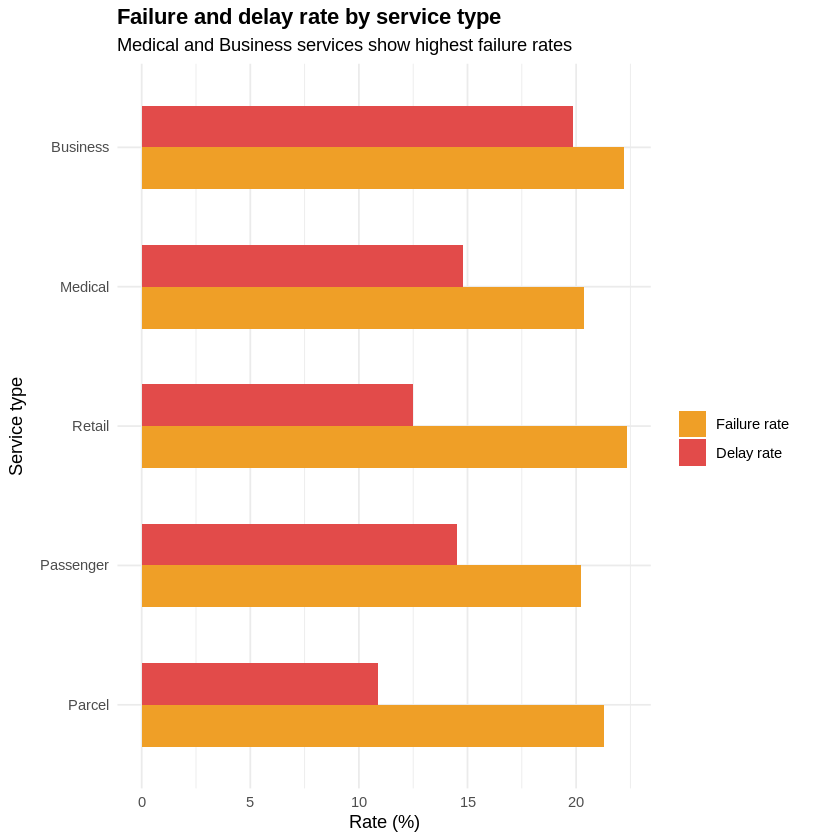

In [ ]:
service_perf <- del_full %>%
  group_by(service_type) %>%
  summarise(
    failure_rate  = mean(failed)   * 100,
    delay_rate    = mean(delayed)  * 100,
    avg_cost      = mean(fuel_or_charge_cost),
    avg_rating    = mean(customer_rating_post_delivery),
    avg_overrides = mean(manual_route_override_count),
    .groups = 'drop'
  )

# Reshape for grouped bar
library(tidyr)
service_long <- service_perf %>%
  select(service_type, failure_rate, delay_rate) %>%
  pivot_longer(cols = c(failure_rate, delay_rate),
               names_to  = 'metric',
               values_to = 'value')

ggplot(service_long, aes(x = reorder(service_type, value),
                          y = value, fill = metric)) +
  geom_bar(stat='identity', position='dodge', width=0.6) +
  scale_fill_manual(values = c('failure_rate'='#E24B4A', 'delay_rate'='#EF9F27'),
                    labels  = c('Failure rate', 'Delay rate')) +
  coord_flip() +
  labs(title    = 'Failure and delay rate by service type',
       subtitle = 'Medical and Business services show highest failure rates',
       x = 'Service type', y = 'Rate (%)', fill = '') +
  theme_minimal() +
  theme(plot.title = element_text(face='bold'))

10. Statistical test: Are failures linked to overrides?

In [ ]:
# Chi-square test: delivery status vs high override count
del_full$high_override <- ifelse(del_full$manual_route_override_count > 1, 'High', 'Low')

override_table <- table(del_full$high_override, del_full$delivery_status)
cat("=== Override count vs Delivery status ===\n")
print(override_table)

chi_result <- chisq.test(override_table)
cat("\n=== Chi-Square Test Result ===\n")
print(chi_result)

if(chi_result$p.value < 0.05) {
  cat("\nConclusion: Significant relationship between route overrides and delivery status (p <0.05)\n")
} else {
  cat("\nConclusion: No significant relationship found (p >=0.05)\n")
}

# T-test: do failed deliveries cost more?
failed_cost  <- del_full$fuel_or_charge_cost[del_full$delivery_status == 'Failed']
ontime_cost  <- del_full$fuel_or_charge_cost[del_full$delivery_status == 'OnTime']

t_result <- t.test(failed_cost, ontime_cost)
cat("\n=== T-Test: Fuel cost — Failed vs OnTime deliveries ===\n")
print(t_result)

if(t_result$p.value < 0.05) {
  cat("\nConclusion: Failed deliveries have significantly different fuel costs (p <0.05)\n")
} else {
  cat("\nConclusion: No significant cost difference found (p >=0.05)\n")
}

=== Override count vs Delivery status ===
      
       Delayed Failed OnTime
  High      57     35    149
  Low      145     97    467

=== Chi-Square Test Result ===

	Pearson's Chi-squared test

data:  override_table
X-squared = 1.411, df = 2, p-value = 0.4939


Conclusion: No significant relationship found (p >=0.05)

=== T-Test: Fuel cost — Failed vs OnTime deliveries ===

	Welch Two Sample t-test

data:  failed_cost and ontime_cost
t = 1.1351, df = 188.42, p-value = 0.2578
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.346686  1.286491
sample estimates:
mean of x mean of y 
 13.14795  12.67805 


Conclusion: No significant cost difference found (p >=0.05)
